In [15]:
from pytools4scarf import dataloader
import matplotlib.pyplot as plt
import numpy as np

In [23]:
dfs, lts = {}, {}

dfs["r059"], lts["r059"] = dataloader.load_lh5_run(
    ["ch001/evt", "ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/data_cleaning.yaml",
    "evt",
    "sp01",
    "p05",
    "r059",
    "phy",
    ["ch001", "ch002"],    
)

dfs["r057"], lts["r057"] = dataloader.load_lh5_run(
    ["ch001/evt", "ch002/evt"],
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/map.yaml",
    "/mnt/atlas01/users/vogl/scarf/sp01/metadata/data_cleaning.yaml",
    "evt",
    "sp01",
    "p05",
    "r057",
    "cal",
    ["ch001", "ch002"],    
)

Survival fraction in ROI : 0.307 (19813/64595)


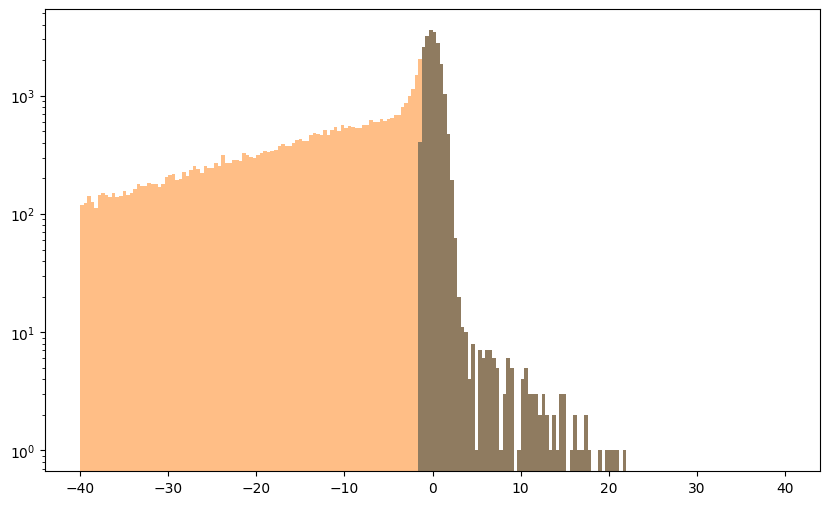

In [ ]:
# df_bg = dfs["r038"]["ch002"]
# mask_bg = df_bg.is_valid_waveform & df_bg.A_max_o_E_High_Side_Cut
df_phy = dfs["r057"]["ch002"]
energymask = (df_phy.trapEftp_fix_cal>1839) & (df_phy.trapEftp_fix_cal<2239)
mask_phy = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0)
total = len(df_phy[mask_phy])
mask_low_cut = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0) & (df_phy.A_max_mw_o_E_fix_Low_Cut)

xrange = (-40, 40)
nbins = 200
fig, ax =plt.subplots(figsize=(10, 6))
vals_2, edges_2 = np.histogram(df_phy[mask_phy]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
vals_2 = vals_2/lts["r057"]/sec_to_day
ax.set_yscale("log")
vals, edges = np.histogram(df_phy[mask_low_cut]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
ax.stairs(vals, edges, fill=True,alpha=1)
ax.stairs(vals_2, edges_2, fill=True,alpha=0.5)
accepted = len(df_phy[mask_low_cut])
sf = accepted/total
print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")

In [25]:
sec_to_day = 1 / (60 * 60 * 24)

Survival fraction in ROI : 0.026 (1306/50135)


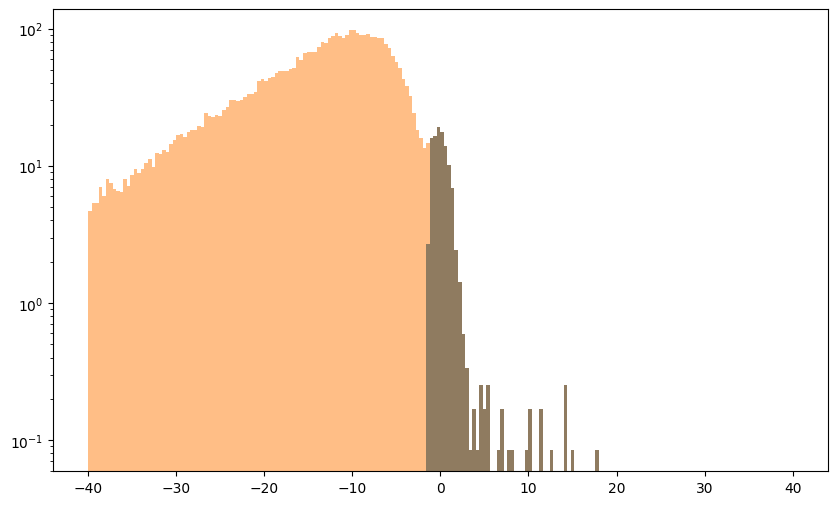

In [27]:
# df_bg = dfs["r038"]["ch002"]
# mask_bg = df_bg.is_valid_waveform & df_bg.A_max_o_E_High_Side_Cut
df_phy = dfs["r059"]["ch002"]
energymask = (df_phy.trapEftp_fix_cal>1839) & (df_phy.trapEftp_fix_cal<2239)
mask_phy = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0)
total = len(df_phy[mask_phy])
mask_low_cut = df_phy.is_valid_waveform & df_phy.A_max_o_E_High_Side_Cut & energymask & (~df_phy.is_muon) & (df_phy.Iasy<0) & (df_phy.A_max_mw_o_E_fix_Low_Cut)

xrange = (-40, 40)
nbins = 200
fig, ax =plt.subplots(figsize=(10, 6))
vals_2, edges_2 = np.histogram(df_phy[mask_phy]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
vals_2 = vals_2/lts["r059"]/sec_to_day
ax.set_yscale("log")
vals, edges = np.histogram(df_phy[mask_low_cut]["A_max_mw_o_E_fix_Classifier"], bins=nbins, range=xrange)
vals = vals/lts["r059"]/sec_to_day
ax.stairs(vals, edges, fill=True,alpha=1)
ax.stairs(vals_2, edges_2, fill=True,alpha=0.5)
accepted = len(df_phy[mask_low_cut])
sf = accepted/total
print(f"Survival fraction in ROI : {sf:.3f} ({accepted}/{total})")